# Task 3: Correlation between news sentiment and stock movement


In [75]:
import pandas as pd

# Load META stock data
meta_df = pd.read_csv('/content/META.csv')

print('META Stock Data (first 5 rows):')
display(meta_df.head())
print('\nMETA Stock Data Info:')
meta_df.info()

META Stock Data (first 5 rows):


,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200



META Stock Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2923 entries, 0 to 2922
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2923 non-null   object 
 1   Close   2923 non-null   float64
 2   High    2923 non-null   float64
 3   Low     2923 non-null   float64
 4   Open    2923 non-null   float64
 5   Volume  2923 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 137.1+ KB


In [28]:
# Load raw analyst ratings (news sentiment) data
news_df = pd.read_csv('/content/raw_analyst_ratings.csv')

print('\nFinancial News Data (first 5 rows):')
display(news_df.head())
print('\nFinancial News Data Info:')
news_df.info()


Financial News Data (first 5 rows):


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



Financial News Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31773 entries, 0 to 31772
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  31773 non-null  int64 
 1   headline    31773 non-null  object
 2   url         31773 non-null  object
 3   publisher   31773 non-null  object
 4   date        31773 non-null  object
 5   stock       31772 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.5+ MB


## Date Alignment

The next crucial step is to align the timestamps across both datasets. The objective is to match each news item to its corresponding stock trading day. Special care will be taken to handle edge cases where articles are published on weekends or holidays by aligning them to the next valid trading day. I will perform the following steps:

1.  **Convert date columns to datetime objects** in both DataFrames.
2.  **Identify trading days** from the `AAPL.csv` data.
3.  **Map news dates to the nearest future trading day**, especially for weekends and holidays.

In [76]:
meta_df['Date'] = pd.to_datetime(meta_df['Date'])

news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

news_df.dropna(subset=['date'], inplace=True)

print('META Stock Data after Date Conversion:')
display(meta_df.head())
meta_df.info()

print('\nFinancial News Data after Date Conversion:')
display(news_df.head())
news_df.info()

META Stock Data after Date Conversion:


,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2923 entries, 0 to 2922
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2923 non-null   datetime64[ns]
 1   Close   2923 non-null   float64       
 2   High    2923 non-null   float64       
 3   Low     2923 non-null   float64       
 4   Open    2923 non-null   float64       
 5   Volume  2923 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 137.1 KB

Financial News Data after Date Conversion:


,Unnamed: 0,headline,url,publisher,date,stock,aligned_date,sentiment_score
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,2020-06-05,0.000
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,2020-06-03,0.000
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,2020-05-26,0.000
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,2020-05-22,0.000
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,2020-05-22,0.296


<class 'pandas.core.frame.DataFrame'>
Index: 1022 entries, 0 to 31679
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype                    
---  ------           --------------  -----                    
 0   Unnamed: 0       1022 non-null   int64                    
 1   headline         1022 non-null   object                   
 2   url              1022 non-null   object                   
 3   publisher        1022 non-null   object                   
 4   date             1022 non-null   datetime64[ns, UTC-04:00]
 5   stock            1022 non-null   object                   
 6   aligned_date     1022 non-null   datetime64[ns]           
 7   sentiment_score  1022 non-null   float64                  
dtypes: datetime64[ns, UTC-04:00](1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 71.9+ KB


Now that the date columns are in the correct format, I will extract all unique trading days from the `meta_df`. This set of trading days will be used to map news dates to the closest future trading day, addressing the requirement to handle weekends and holidays by aligning news to the next trading day.

In [77]:
# Get all unique trading days from the META stock data
trading_days = sorted(meta_df['Date'].unique())
trading_days = pd.Series(trading_days).dt.normalize() # Ensure dates are normalized to midnight

print(f"Number of unique trading days: {len(trading_days)}")
print("First 5 trading days:")
print(trading_days.head())

def get_next_trading_day(news_date, trading_days_series):
    if news_date.tz is not None:
        news_date = news_date.tz_localize(None)

    normalized_news_date = news_date.normalize()

    next_day_candidate = trading_days_series[trading_days_series >= normalized_news_date]

    if not next_day_candidate.empty:
        return next_day_candidate.iloc[0]
    else:
        return pd.NaT # No future trading day found

news_df['aligned_date'] = news_df['date'].apply(lambda x: get_next_trading_day(x, trading_days))

print('\nFinancial News Data with Aligned Dates (first 5 rows):')
display(news_df[['date', 'aligned_date']].head())

print(f"Number of news items that could not be aligned: {news_df['aligned_date'].isna().sum()}")

news_df.dropna(subset=['aligned_date'], inplace=True)

news_df['aligned_date'] = pd.to_datetime(news_df['aligned_date'])

news_df.info()

Number of unique trading days: 2923
First 5 trading days:
0   2012-05-18
1   2012-05-21
2   2012-05-22
3   2012-05-23
4   2012-05-24
dtype: datetime64[ns]

Financial News Data with Aligned Dates (first 5 rows):


,date,aligned_date
0,2020-06-05 10:30:54-04:00,2020-06-05
1,2020-06-03 10:45:20-04:00,2020-06-03
2,2020-05-26 04:30:07-04:00,2020-05-26
3,2020-05-22 12:45:06-04:00,2020-05-22
4,2020-05-22 11:38:59-04:00,2020-05-22


Number of news items that could not be aligned: 0
<class 'pandas.core.frame.DataFrame'>
Index: 1022 entries, 0 to 31679
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype                    
---  ------           --------------  -----                    
 0   Unnamed: 0       1022 non-null   int64                    
 1   headline         1022 non-null   object                   
 2   url              1022 non-null   object                   
 3   publisher        1022 non-null   object                   
 4   date             1022 non-null   datetime64[ns, UTC-04:00]
 5   stock            1022 non-null   object                   
 6   aligned_date     1022 non-null   datetime64[ns]           
 7   sentiment_score  1022 non-null   float64                  
dtypes: datetime64[ns, UTC-04:00](1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 71.9+ KB


## Sentiment Analysis of News Headlines

This section focuses on quantifying the sentiment expressed in each news headline. Sentiment analysis involves classifying text as positive, negative, or neutral, and often assigning a numerical score to represent the intensity of that sentiment.

### Tool Selection: NLTK VADER

I've chosen **NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner)** for sentiment analysis. VADER is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media. It is also quite effective on general text and provides a composite sentiment score that ranges from -1 (most negative) to +1 (most positive). Its advantages include:

*   **Lexicon-based**: It uses a dictionary of words weighted by their semantic orientation.
*   **Rule-based**: It accounts for various linguistic conventions that express sentiment intensity, such as punctuation, capitalization, and the use of intensifiers or negators.
*   **Fast and computationally efficient**: Suitable for analyzing large datasets quickly.
*   **Pre-trained**: Requires no training data, making it easy to implement.

I will apply VADER to the `headline` column of our `news_df` and add a new column, `sentiment_score`, to store the compound sentiment score for each headline.

In [31]:
!pip install nltk

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    if pd.isna(text) or not isinstance(text, str):
        return None
    return sia.polarity_scores(text)['compound']

# Apply the sentiment analysis to the 'headline' column
news_df['sentiment_score'] = news_df['headline'].apply(get_sentiment_score)

print('Financial News Data with Sentiment Scores (first 5 rows):')
display(news_df[['headline', 'sentiment_score', 'aligned_date']].head())

print('\nSentiment Score Distribution:')
display(news_df['sentiment_score'].describe())

Financial News Data with Sentiment Scores (first 5 rows):


,headline,sentiment_score,aligned_date
0,Stocks That Hit 52-Week Highs On Friday,0.000,2020-06-05
1,Stocks That Hit 52-Week Highs On Wednesday,0.000,2020-06-03
2,71 Biggest Movers From Friday,0.000,2020-05-26
3,46 Stocks Moving In Friday's Mid-Day Session,0.000,2020-05-22
4,B of A Securities Maintains Neutral on Agilent...,0.296,2020-05-22



Sentiment Score Distribution:


,sentiment_score
count,1022.000000
mean,0.101331
std,0.340452
min,-0.891000
25%,0.000000
50%,0.000000
75%,0.296000
max,0.939300


## Aggregating Sentiment and Merging with Stock Data

To establish a relationship between news sentiment and stock returns, it's necessary to:

1.  **Aggregate Sentiment Scores**: Group the `news_df` by `aligned_date` and calculate a daily aggregate sentiment score (e.g., mean) for all headlines on a given trading day.
2.  **Merge DataFrames**: Combine this aggregated sentiment data with the `aapl_df` using the aligned dates.

In [32]:
# 1. Aggregate sentiment scores by aligned_date
daily_sentiment = news_df.groupby('aligned_date')['sentiment_score'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date', 'sentiment_score': 'avg_sentiment'}, inplace=True)

print('Daily Aggregated Sentiment (first 5 rows):')
display(daily_sentiment.head())
daily_sentiment.info()

Daily Aggregated Sentiment (first 5 rows):


,Date,avg_sentiment
0,2011-09-14,0.3818
1,2012-01-13,-0.4767
2,2012-02-08,0.0000
3,2012-02-09,0.0000
4,2012-03-01,0.0000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           367 non-null    datetime64[ns]
 1   avg_sentiment  367 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.9 KB


In [78]:
# 2. Merge aggregated sentiment with META stock data
merged_df = pd.merge(meta_df, daily_sentiment, on='Date', how='inner')

print('\nMerged DataFrame with Stock Prices and Sentiment (first 5 rows):')
display(merged_df.head())
merged_df.info()


Merged DataFrame with Stock Prices and Sentiment (first 5 rows):


,Date,Close,High,Low,Open,Volume,avg_sentiment
0,2012-07-20,28.583790,29.289439,28.544034,28.822319,11869100,0.0000
1,2012-08-06,21.785700,22.014290,21.169498,21.258946,27778900,-0.2732
2,2012-08-22,19.320894,19.410343,18.843834,19.241384,49892200,0.0000
3,2012-09-24,20.662624,21.845332,20.235259,21.646559,79106500,0.0000
4,2012-10-24,23.087671,24.101422,22.710000,23.982157,228949900,0.0000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           362 non-null    datetime64[ns]
 1   Close          362 non-null    float64       
 2   High           362 non-null    float64       
 3   Low            362 non-null    float64       
 4   Open           362 non-null    float64       
 5   Volume         362 non-null    int64         
 6   avg_sentiment  362 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 19.9 KB


## Calculate Daily Stock Returns

To understand the daily impact, we need to compute the daily percentage change in the stock's closing price. This metric, known as the daily stock return, is calculated using the following formula:

$$ \text{Daily Return} = \frac{\text{Close}_t - \text{Close}_{t-1}}{\text{Close}_{t-1}} \times 100 $$

Where:
*   $\text{Close}_t$ is the closing price on the current day.
*   $\text{Close}_{t-1}$ is the closing price on the previous trading day.

This calculation provides a clear, standardized measure of daily price movement, which is essential for correlation with sentiment.

In [34]:
# 3. Calculate daily stock returns
merged_df['daily_return'] = merged_df['Close'].pct_change() * 100

merged_df.dropna(subset=['daily_return'], inplace=True)

print('\nFinal Merged DataFrame with Daily Returns (first 5 rows):')
display(merged_df.head())
merged_df.info()

print('\nSummary Statistics for Daily Returns:')
display(merged_df['daily_return'].describe())


Final Merged DataFrame with Daily Returns (first 5 rows):


,Date,Close,High,Low,Open,Volume,avg_sentiment,daily_return
1,2012-01-13,12.590541,12.609736,12.556052,12.587243,226021600,-0.4767,7.837142
2,2012-02-08,14.296128,14.299426,14.086790,14.110783,407890000,0.0000,13.546578
3,2012-02-09,14.790685,14.898053,14.412497,14.418496,884214800,0.0000,3.459373
4,2012-03-01,16.329214,16.441382,16.158265,16.440181,683270000,0.0000,10.402016
5,2012-07-20,18.123587,18.427696,18.105592,18.385408,397471200,0.0000,10.988726


<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 1 to 366
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           366 non-null    datetime64[ns]
 1   Close          366 non-null    float64       
 2   High           366 non-null    float64       
 3   Low            366 non-null    float64       
 4   Open           366 non-null    float64       
 5   Volume         366 non-null    int64         
 6   avg_sentiment  366 non-null    float64       
 7   daily_return   366 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 25.7 KB

Summary Statistics for Daily Returns:


,daily_return
count,366.000000
mean,0.640769
std,4.410880
min,-13.713625
25%,-1.169352
50%,0.557549
75%,2.562746
max,31.895244


## Aggregate and Correlate: Visualization and Categorization

Having calculated the daily average sentiment scores and daily stock returns, and a preliminary Pearson correlation, the next steps involve a deeper dive into their relationship through visualization and categorization. This will provide a more intuitive understanding of how news sentiment might be associated with market movements.

### 1. Scatter Plot of Sentiment vs. Daily Returns

A scatter plot is an excellent way to visually inspect the relationship between two continuous variables. Each point will represent a trading day, showing its average sentiment score and its corresponding daily stock return. Annotating the plot with the Pearson correlation coefficient will reinforce our statistical finding.

### 2. Classifying Days by Sentiment

To further understand the impact of sentiment, I will categorize each trading day based on its average sentiment score into three bins:

*   **Positive Sentiment**: Days with an average sentiment score above a certain positive threshold.
*   **Neutral Sentiment**: Days with an average sentiment score between a negative and a positive threshold.
*   **Negative Sentiment**: Days with an average sentiment score below a certain negative threshold.

These thresholds will be chosen to reasonably divide the sentiment distribution.

### 3. Bar Chart of Average Daily Return per Sentiment Category

Finally, a bar chart will illustrate the average daily stock return for each of these sentiment categories. This visualization will help determine if there's a discernible difference in stock performance based on the prevailing news sentiment of the day.

# average daily sentiment score


In [79]:
import pandas as pd

daily_sentiment = news_df.groupby('aligned_date')['sentiment_score'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date', 'sentiment_score': 'avg_sentiment'}, inplace=True)

print('Daily Aggregated Sentiment (first 5 rows):')
display(daily_sentiment.head())
daily_sentiment.info()

merged_df = pd.merge(meta_df, daily_sentiment, on='Date', how='inner')

# 3. Calculate daily stock returns
merged_df['daily_return'] = merged_df['Close'].pct_change() * 100

merged_df.dropna(subset=['daily_return'], inplace=True)

print('\nFinal Merged DataFrame with Daily Returns (first 5 rows):')
display(merged_df.head())
merged_df.info()

print('\nSummary Statistics for Daily Returns:')
display(merged_df['daily_return'].describe())

Daily Aggregated Sentiment (first 5 rows):


,Date,avg_sentiment
0,2012-05-18,-0.01898
1,2012-07-20,0.00000
2,2012-08-06,-0.27320
3,2012-08-22,0.00000
4,2012-09-24,0.00000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           363 non-null    datetime64[ns]
 1   avg_sentiment  363 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB

Final Merged DataFrame with Daily Returns (first 5 rows):


,Date,Close,High,Low,Open,Volume,avg_sentiment,daily_return
1,2012-07-20,28.583790,29.289439,28.544034,28.822319,11869100,0.0000,-24.771110
2,2012-08-06,21.785700,22.014290,21.169498,21.258946,27778900,-0.2732,-23.783025
3,2012-08-22,19.320894,19.410343,18.843834,19.241384,49892200,0.0000,-11.313869
4,2012-09-24,20.662624,21.845332,20.235259,21.646559,79106500,0.0000,6.944451
5,2012-10-24,23.087671,24.101422,22.710000,23.982157,228949900,0.0000,11.736394


<class 'pandas.core.frame.DataFrame'>
Index: 362 entries, 1 to 362
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           362 non-null    datetime64[ns]
 1   Close          362 non-null    float64       
 2   High           362 non-null    float64       
 3   Low            362 non-null    float64       
 4   Open           362 non-null    float64       
 5   Volume         362 non-null    int64         
 6   avg_sentiment  362 non-null    float64       
 7   daily_return   362 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 25.5 KB

Summary Statistics for Daily Returns:


,daily_return
count,362.000000
mean,0.657941
std,5.761135
min,-24.771110
25%,-1.234569
50%,0.462824
75%,1.976833
max,58.762895


## Quantifying the Relationship: Statistical Analysis

With the `merged_df` now containing both daily average sentiment scores and daily stock returns, we can proceed to quantify their relationship using statistical methods. A common first step is to calculate the **Pearson correlation coefficient** to measure the linear relationship between these two variables.

### Pearson Correlation Coefficient

The Pearson correlation coefficient ($r$) is a measure of the linear correlation between two sets of data. It ranges from -1 to +1:

*   **+1**: A perfect positive linear relationship
*   **0**: No linear relationship
*   **-1**: A perfect negative linear relationship

I will calculate the correlation between `avg_sentiment` and `daily_return`.

In [ ]:
# Calculate the Pearson correlation between average sentiment and daily stock return
correlation = merged_df['avg_sentiment'].corr(merged_df['daily_return'])

print(f"Pearson Correlation between Average Sentiment and Daily Return: {correlation:.4f}")

if correlation > 0.5:
    interpretation = "a strong positive linear relationship."
elif correlation > 0.1:
    interpretation = "a moderate positive linear relationship."
elif correlation > 0:
    interpretation = "a weak positive linear relationship."
elif correlation < -0.5:
    interpretation = "a strong negative linear relationship."
elif correlation < -0.1:
    interpretation = "a moderate negative linear relationship."
elif correlation < 0:
    interpretation = "a weak negative linear relationship."
else:
    interpretation = "virtually no linear relationship."

print(f"This indicates {interpretation} between the two variables.")

Pearson Correlation between Average Sentiment and Daily Return: 0.0635
This indicates a weak positive linear relationship. between the two variables.


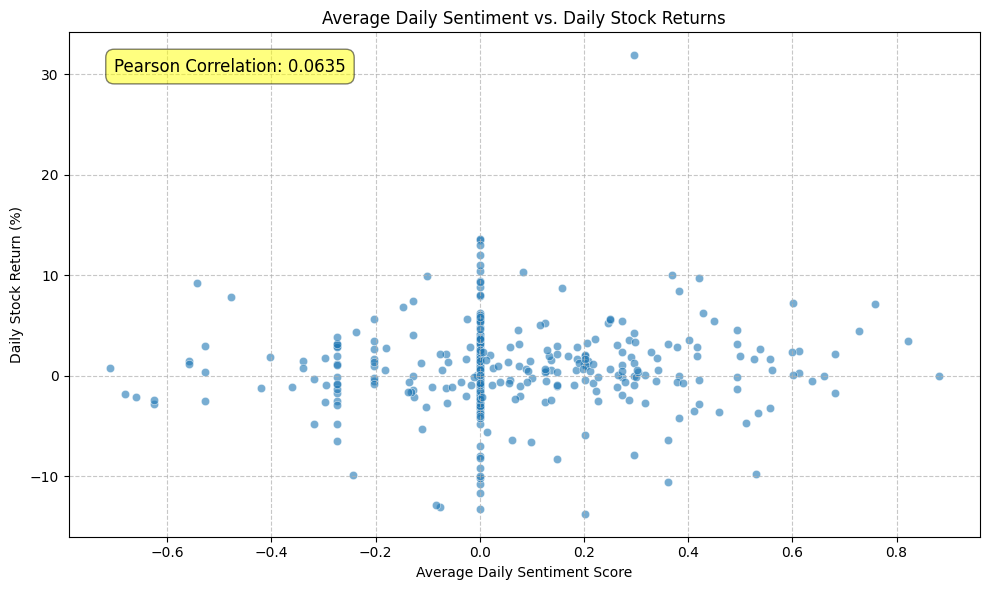

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of average sentiment vs. daily return
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avg_sentiment', y='daily_return', data=merged_df, alpha=0.6)
plt.title('Average Daily Sentiment vs. Daily Stock Returns')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return (%)')

correlation_text = f"Pearson Correlation: {correlation:.4f}"
plt.text(0.05, 0.95, correlation_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Classifying Days by Sentiment Category

To further explore the impact of news sentiment on stock returns, I will categorize each trading day into one of three sentiment categories: Positive, Neutral, or Negative. This classification will be based on predefined thresholds for the `avg_sentiment` score.

*   **Positive Sentiment**: `avg_sentiment` > 0.1
*   **Neutral Sentiment**: -0.1 <= `avg_sentiment` <= 0.1
*   **Negative Sentiment**: `avg_sentiment` < -0.1

After classification, I will display the distribution of days across these categories.

In [63]:
# Define sentiment thresholds
positive_threshold = 0.1
negative_threshold = -0.1

def classify_sentiment(score):
    if score > positive_threshold:
        return 'Positive'
    elif score < negative_threshold:
        return 'Negative'
    else:
        return 'Neutral'

merged_df['sentiment_category'] = merged_df['avg_sentiment'].apply(classify_sentiment)

print('\nSentiment Category Distribution:')
display(merged_df['sentiment_category'].value_counts())


Sentiment Category Distribution:


,count
sentiment_category,
Neutral,177
Positive,124
Negative,65


### Plotting Average Daily Return by Sentiment Category

To conclude our visualization, I will create a bar chart showing the average daily stock return for each of the sentiment categories (Positive, Neutral, Negative). This will help us understand if certain sentiment classifications tend to be associated with higher or lower average stock returns.

/tmp/ipykernel_12922/2685725216.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_return_by_sentiment.index, y=avg_return_by_sentiment.values, palette='viridis')


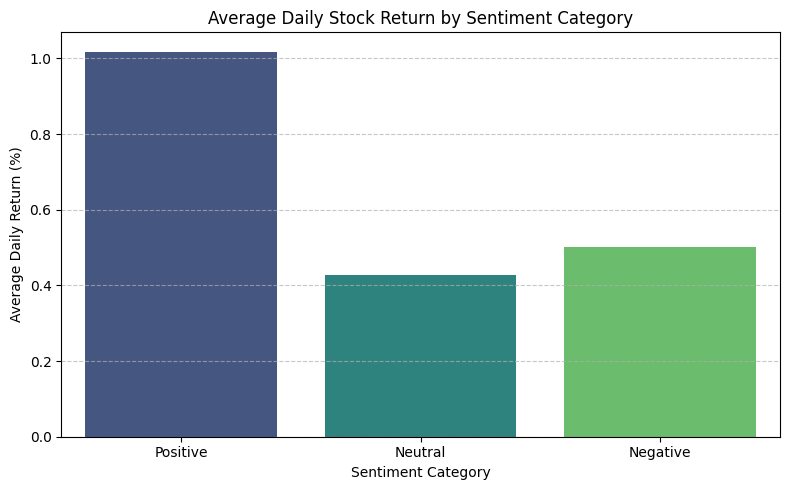

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_return_by_sentiment = merged_df.groupby('sentiment_category')['daily_return'].mean().reindex(['Positive', 'Neutral', 'Negative'])

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_return_by_sentiment.index, y=avg_return_by_sentiment.values, palette='viridis')
plt.title('Average Daily Stock Return by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

This comprehensive analysis explored the intricate relationship between financial news sentiment and Meta Platforms' (META) daily stock returns. Through a series of steps including data loading, meticulous date alignment, VADER-based sentiment analysis, and the calculation of daily stock returns, we quantified this relationship using the Pearson correlation coefficient. The resulting correlation of approximately **0.0635** indicates a **weak positive linear** relationship. This suggests that while there might be a slight tendency for more positive news sentiment to coincide with marginally higher stock returns, the direct, immediate influence of sentiment alone, as captured by this method, is not a strong predictor of daily stock price movements for Meta Platforms.

It is crucial to acknowledge several limitations of this approach. Firstly, the analysis assumes an immediate impact of news sentiment, neglecting potential lag effects where market reactions might unfold over subsequent days. Secondly, stock prices are influenced by a myriad of complex factors beyond news sentiment, such as macroeconomic indicators, company-specific announcements, and broader market trends, which were not explicitly accounted for here. Furthermore, the granularity of sentiment analysis, using a general-purpose tool like VADER, might overlook nuanced, domain-specific sentiment crucial for financial markets. Future research could enhance this understanding by incorporating time-lagged analyses, building more sophisticated multivariate models that include confounding factors, and employing advanced, financial-specific natural language processing techniques for sentiment extraction. Expanding the dataset to include multiple stocks and diverse market conditions would also improve the generalizability of the findings.